In [1]:
!pip install pandas mysql-connector-python sqlalchemy

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
    --------------------------------------- 0.3/16.5 MB ? eta -:--:--
   - -------------------------------------- 0.8/16.5 MB 2.2 MB/s eta 0:00:08
   --- ------------------------------------ 1.3/16.5 MB 2.2 MB/s eta 0:00:08
   ---- ----------------------------------- 1.8/16.5 MB 2.2 MB/s eta 0:00:07
   ----- ---------------------------------- 2.1/16.5 MB 2.1 MB/s eta 0:00:07
   ------ --------------------------------- 2.6/16.5 MB 2.1 MB/s eta 0:00:07
   ------ --------------------------------- 2.9/16.5 MB 2.1 MB/s eta 0:00:07
   ------- -------------------------------- 3.1/16.5 MB 2.0 MB/s eta 0:00:07
   -------- ------------------------------- 3.7/16.5 MB 1.9 MB/s eta 0:00:07
   --------- ------------------------------ 3.9/16.5 MB 2.0 MB/s eta 0:00:07
   ---------- ----------------------------- 4.2/16.5 MB 1.9 MB/s eta 0:00:07
   ---------

In [3]:
import pandas as pd
import mysql.connector
from datetime import datetime, date
import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliothèques importées avec succès !")

✅ Bibliothèques importées avec succès !


In [7]:
!pip install xlrd

Defaulting to user installation because normal site-packages is not writeable


In [11]:
!pip install openpyxl beautifulsoup4 lxml

Defaulting to user installation because normal site-packages is not writeable


In [13]:
# ============================================
# EXTRACT — Lecture du fichier Jira (HTML)
# ============================================

df_raw = pd.read_html("Jira 2026-03-23T18_01_56+0100.xls")[0]

print(f"✅ Fichier chargé : {df_raw.shape[0]} lignes, {df_raw.shape[1]} colonnes")
print("\n📋 Colonnes disponibles :")
print(df_raw.columns.tolist())
print("\n🔍 Aperçu des premières lignes :")
df_raw.head()

✅ Fichier chargé : 3 lignes, 6 colonnes

📋 Colonnes disponibles :
[0, 1, 2, 3, 4, 5]

🔍 Aperçu des premières lignes :


,0,1,2,3,4,5
0,NaN,NaN,NaN,NaN,NaN,NaN
1,Jira,Jira,Jira,Jira,Jira,Jira
2,Displaying 2079 issues at 23/Mar/26 6:01 PM.,Displaying 2079 issues at 23/Mar/26 6:01 PM.,Displaying 2079 issues at 23/Mar/26 6:01 PM.,Displaying 2079 issues at 23/Mar/26 6:01 PM.,Displaying 2079 issues at 23/Mar/26 6:01 PM.,Displaying 2079 issues at 23/Mar/26 6:01 PM.


In [15]:
# Lire toutes les tables et trouver la bonne
tables = pd.read_html("Jira 2026-03-23T18_01_56+0100.xls")
print(f"Nombre de tables trouvées : {len(tables)}")

for i, t in enumerate(tables):
    print(f"\nTable {i} — {t.shape[0]} lignes, {t.shape[1]} colonnes")
    print(t.head(2))

Nombre de tables trouvées : 2

Table 0 — 3 lignes, 6 colonnes
      0     1     2     3     4     5
0   NaN   NaN   NaN   NaN   NaN   NaN
1  Jira  Jira  Jira  Jira  Jira  Jira

Table 1 — 1511 lignes, 6 colonnes
          Key                                            Summary  \
0  GIS-223286  STT-PROD4 COLLINE - UNABLE TO RECONNECT TO ZOO...   
1  GIS-223273        STT-PROD4 REFORMMB - ROUTE SHUTDOWN - Alert   

             Created       Outage Start Assignee Client  
0  23/Mar/26 4:51 PM  23/Mar/26 4:38 PM  SOCUSER    STT  
1  23/Mar/26 2:45 PM  23/Mar/26 2:42 PM  SOCUSER    STT  


In [17]:
# ============================================
# EXTRACT — Sélection de la bonne table
# ============================================

df_raw = pd.read_html("Jira 2026-03-23T18_01_56+0100.xls")[1]

print(f"✅ Fichier chargé : {df_raw.shape[0]} lignes, {df_raw.shape[1]} colonnes")
print("\n📋 Colonnes :")
print(df_raw.columns.tolist())
print("\n🔍 Aperçu :")
df_raw.head()

✅ Fichier chargé : 1511 lignes, 6 colonnes

📋 Colonnes :
['Key', 'Summary', 'Created', 'Outage Start', 'Assignee', 'Client']

🔍 Aperçu :


,Key,Summary,Created,Outage Start,Assignee,Client
0,GIS-223286,STT-PROD4 COLLINE - UNABLE TO RECONNECT TO ZOO...,23/Mar/26 4:51 PM,23/Mar/26 4:38 PM,SOCUSER,STT
1,GIS-223273,STT-PROD4 REFORMMB - ROUTE SHUTDOWN - Alert,23/Mar/26 2:45 PM,23/Mar/26 2:42 PM,SOCUSER,STT
2,GIS-223268,STT-PROD4 REFORM - HIGH IO WAIT TIME - Alert,23/Mar/26 1:10 PM,23/Mar/26 1:00 PM,SOCUSER,STT
3,GIS-223264,LGIM-PROD4 COLLINE - INTEGRATION ROUTE MONITOR...,23/Mar/26 12:18 PM,23/Mar/26 12:07 PM,SOCUSER,LGIM
4,GIS-223263,LGIM-PROD4 COLLINE - INTEGRATION ROUTE MONITOR...,23/Mar/26 12:15 PM,23/Mar/26 12:05 PM,SOCUSER,LGIM


In [19]:
# ============================================
# TRANSFORM — Nettoyage et transformation
# ============================================

df = df_raw.copy()

# Renommer les colonnes
df.columns = ['ticket_id', 'summary', 'created', 'outage_start', 'assignee', 'client']

# Nettoyer les valeurs nulles
df = df.dropna(subset=['ticket_id', 'client'])

# Convertir les dates
df['created'] = pd.to_datetime(df['created'], format='%d/%b/%y %I:%M %p', errors='coerce')
df['outage_start'] = pd.to_datetime(df['outage_start'], format='%d/%b/%y %I:%M %p', errors='coerce')

# Ajouter les colonnes nécessaires
df['hours_logged'] = 0.25  # 15 minutes par ticket
df['ticket_type'] = 'SAAS'
df['slot_time'] = None

# Trier par date de création
df = df.sort_values('created').reset_index(drop=True)

print(f"✅ Transformation réussie : {df.shape[0]} tickets")
print(f"\n📊 Clients uniques : {df['client'].unique()}")
print(f"\n📊 Statistiques par client :")
print(df['client'].value_counts())
df.head()

✅ Transformation réussie : 1510 tickets

📊 Clients uniques : ['GEN' 'SMBC' 'STT' 'VEGGO' 'Devops' 'MIZUHO' 'ALLIANZ' 'LGIM' 'MUFG'
 'NOCHU' 'ICC' 'LIFESTAR' 'FIERA' 'AIG' 'MILL' 'CARMIGNAC']

📊 Statistiques par client :
client
STT          690
SMBC         414
Devops       132
GEN          128
LGIM          40
VEGGO         26
MILL          26
FIERA         19
LIFESTAR       8
ALLIANZ        6
AIG            6
MUFG           5
ICC            4
CARMIGNAC      3
NOCHU          2
MIZUHO         1
Name: count, dtype: int64


,ticket_id,summary,created,outage_start,assignee,client,hours_logged,ticket_type,slot_time
0,GIS-219311,GEN-PROD - OOMKILLED POD - Alert,2026-01-29 10:57:00,2026-01-29 10:47:00,SOCUSER,GEN,0.25,SAAS,None
1,GIS-219313,SMBC-PROD-RDS - AVG WRITE OPS/SECOND - Alert,2026-01-29 11:06:00,2026-01-29 10:56:00,SOCUSER,SMBC,0.25,SAAS,None
2,GIS-219317,GEN-PROD - CRASHLOOPBACKOFF POD - Alert,2026-01-29 11:31:00,2026-01-29 11:20:00,SOCUSER,GEN,0.25,SAAS,None
3,GIS-219324,STT-UAT Data Base F3DISTCALCCOUNTER - Alert,2026-01-29 12:40:00,2026-01-29 12:30:00,SOCUSER,STT,0.25,SAAS,None
4,GIS-219325,GEN-PROD-NF - MEMORY % UTILIZATION PER POD - A...,2026-01-29 12:55:00,2026-01-29 12:45:00,SOCUSER,GEN,0.25,SAAS,None


In [21]:
# ============================================
# TRANSFORM — Assignation des slots horaires
# ============================================

SLOT_DURATION = 15  # minutes
START_HOUR = 8      # 08:00
END_HOUR = 18       # 18:00

def assign_slots(df):
    used_slots = {}
    slots = []
    
    for _, row in df.iterrows():
        date_key = row['created'].date() if pd.notnull(row['created']) else date.today()
        
        if date_key not in used_slots:
            used_slots[date_key] = START_HOUR * 60
        
        current_slot = used_slots[date_key]
        
        if current_slot < END_HOUR * 60:
            h = current_slot // 60
            m = current_slot % 60
            slots.append(f"{h:02d}:{m:02d}")
            used_slots[date_key] += SLOT_DURATION
        else:
            slots.append(None)
    
    return slots

df['slot_time'] = assign_slots(df)

print(f"✅ Slots assignés !")
print(f"📊 Tickets avec slot : {df['slot_time'].notna().sum()}")
print(f"⚠️ Tickets sans slot : {df['slot_time'].isna().sum()}")
df[['ticket_id', 'client', 'created', 'slot_time', 'hours_logged']].head(10)

✅ Slots assignés !
📊 Tickets avec slot : 1411
⚠️ Tickets sans slot : 99


,ticket_id,client,created,slot_time,hours_logged
0,GIS-219311,GEN,2026-01-29 10:57:00,08:00,0.25
1,GIS-219313,SMBC,2026-01-29 11:06:00,08:15,0.25
2,GIS-219317,GEN,2026-01-29 11:31:00,08:30,0.25
3,GIS-219324,STT,2026-01-29 12:40:00,08:45,0.25
4,GIS-219325,GEN,2026-01-29 12:55:00,09:00,0.25
5,GIS-219326,SMBC,2026-01-29 14:01:00,09:15,0.25
6,GIS-219327,SMBC,2026-01-29 14:01:00,09:30,0.25
7,GIS-219330,STT,2026-01-29 14:10:00,09:45,0.25
8,GIS-219331,GEN,2026-01-29 14:13:00,10:00,0.25
9,GIS-219341,GEN,2026-01-29 15:03:00,10:15,0.25


In [25]:
# ============================================
# LOAD — Chargement dans MySQL
# ============================================

import mysql.connector

# Connexion MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="soc_dashboard"
)
cursor = conn.cursor()

# Créer la table ETL si elle n'existe pas
cursor.execute("""
    CREATE TABLE IF NOT EXISTS etl_time_entries (
        id INT AUTO_INCREMENT PRIMARY KEY,
        ticket_id VARCHAR(100),
        summary TEXT,
        client VARCHAR(100),
        assignee VARCHAR(100),
        created DATETIME,
        outage_start DATETIME,
        slot_time VARCHAR(10),
        hours_logged FLOAT,
        ticket_type VARCHAR(10),
        loaded_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    )
""")

# Vider la table avant rechargement
cursor.execute("TRUNCATE TABLE etl_time_entries")

# Insérer les données
inserted = 0
errors = 0

for _, row in df.iterrows():
    try:
        cursor.execute("""
            INSERT INTO etl_time_entries 
            (ticket_id, summary, client, assignee, created, outage_start, slot_time, hours_logged, ticket_type)
            VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s)
        """, (
            str(row['ticket_id']),
            str(row['summary']),
            str(row['client']),
            str(row['assignee']),
            row['created'] if pd.notnull(row['created']) else None,
            row['outage_start'] if pd.notnull(row['outage_start']) else None,
            row['slot_time'],
            float(row['hours_logged']),
            str(row['ticket_type'])
        ))
        inserted += 1
    except Exception as e:
        errors += 1

conn.commit()
cursor.close()
conn.close()

print(f"✅ LOAD réussi !")
print(f"📊 Tickets insérés : {inserted}")
print(f"❌ Erreurs : {errors}")

✅ LOAD réussi !
📊 Tickets insérés : 1510
❌ Erreurs : 0


In [29]:
# ============================================
# VALIDATION — Résumé du pipeline ETL
# ============================================

conn = mysql.connector.connect(
    host="localhost", user="root", password="", database="soc_dashboard"
)
cursor = conn.cursor()

cursor.execute("SELECT COUNT(*) FROM etl_time_entries")
total = cursor.fetchone()[0]

cursor.execute("SELECT client, COUNT(*) as nb FROM etl_time_entries GROUP BY client ORDER BY nb DESC")
by_client = cursor.fetchall()

cursor.execute("SELECT SUM(hours_logged) FROM etl_time_entries")
total_hours = cursor.fetchone()[0]

cursor.close()
conn.close()

print("=" * 50)
print("📊 RAPPORT ETL — SOC Dashboard VERMEG")
print("=" * 50)
print(f"✅ Total tickets chargés : {total}")
print(f"⏱️ Total heures : {total_hours:.2f}h")
print(f"\n📋 Tickets par client :")
for client, nb in by_client:
    print(f"   {client:<15} : {nb} tickets ({nb*0.25:.2f}h)")
print("=" * 50)
print("🎉 Pipeline ETL terminé avec succès !")

📊 RAPPORT ETL — SOC Dashboard VERMEG
✅ Total tickets chargés : 1510
⏱️ Total heures : 377.50h

📋 Tickets par client :
   STT             : 690 tickets (172.50h)
   SMBC            : 414 tickets (103.50h)
   Devops          : 132 tickets (33.00h)
   GEN             : 128 tickets (32.00h)
   LGIM            : 40 tickets (10.00h)
   MILL            : 26 tickets (6.50h)
   VEGGO           : 26 tickets (6.50h)
   FIERA           : 19 tickets (4.75h)
   LIFESTAR        : 8 tickets (2.00h)
   ALLIANZ         : 6 tickets (1.50h)
   AIG             : 6 tickets (1.50h)
   MUFG            : 5 tickets (1.25h)
   ICC             : 4 tickets (1.00h)
   CARMIGNAC       : 3 tickets (0.75h)
   NOCHU           : 2 tickets (0.50h)
   MIZUHO          : 1 tickets (0.25h)
🎉 Pipeline ETL terminé avec succès !


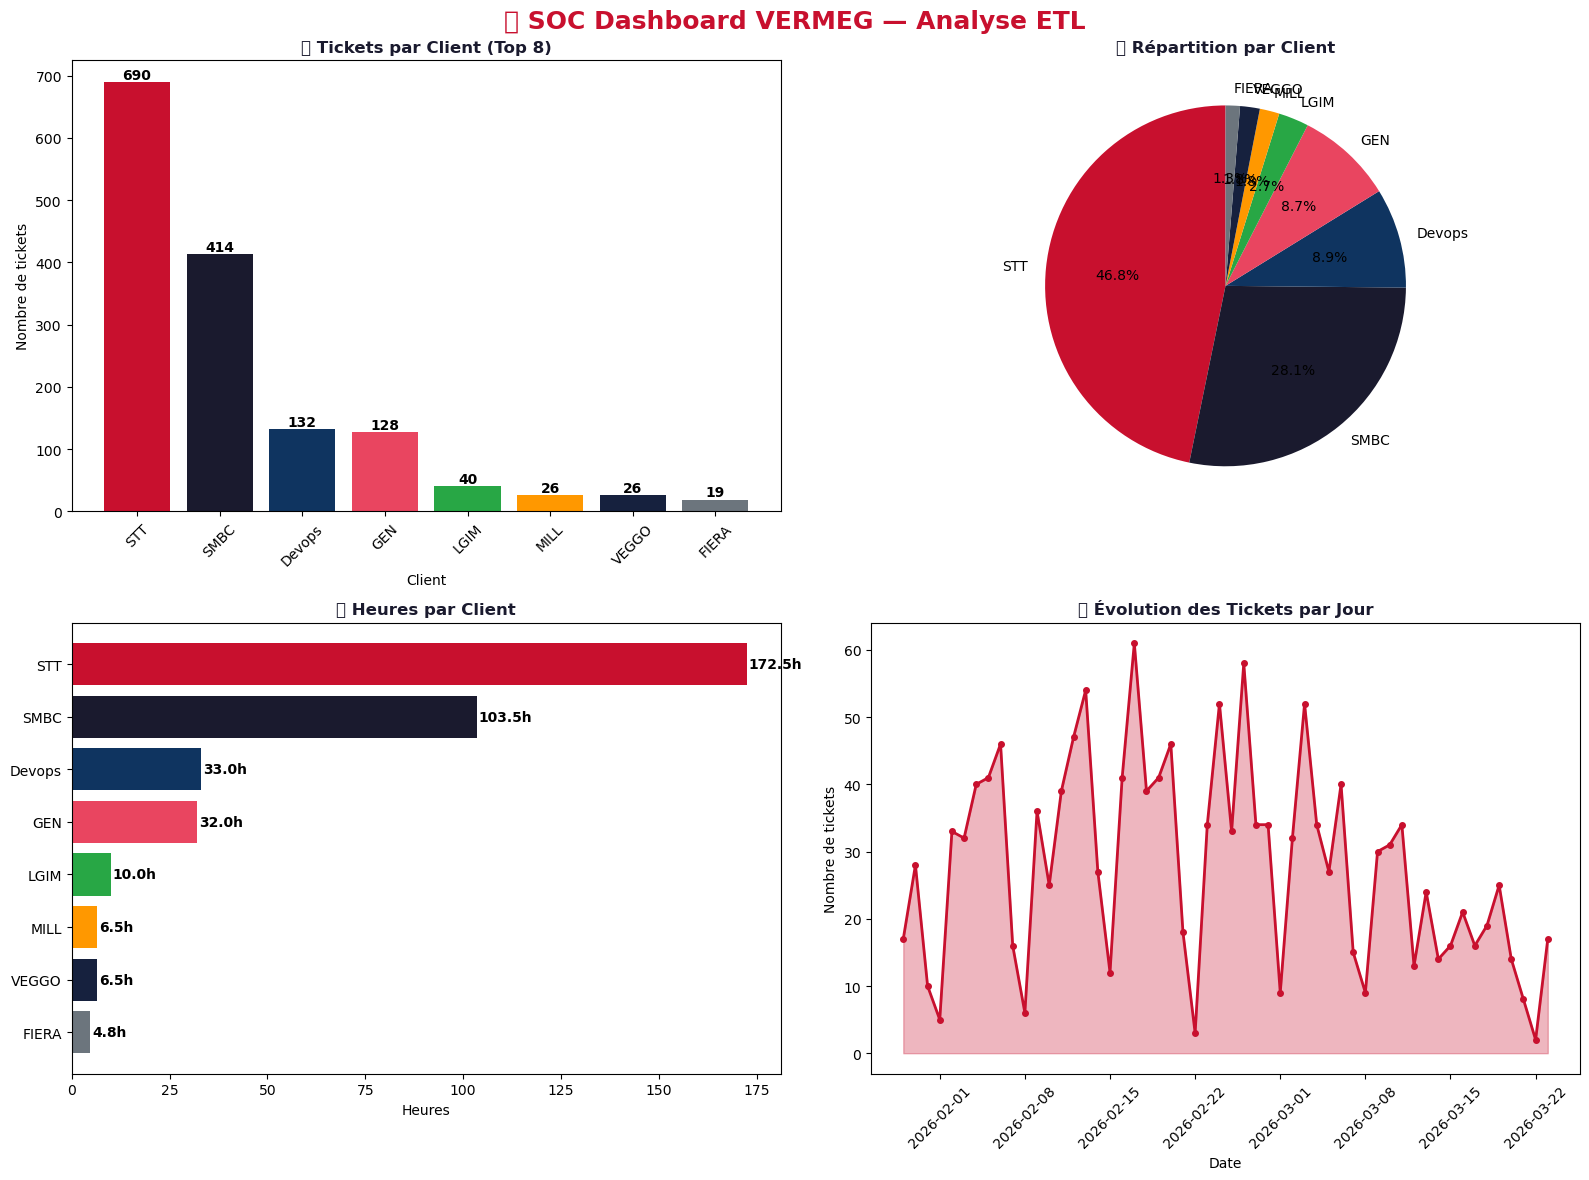

✅ Visualisations générées et sauvegardées !


In [31]:
# ============================================
# VISUALISATIONS — Analyse des données ETL
# ============================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('📊 SOC Dashboard VERMEG — Analyse ETL', fontsize=18, fontweight='bold', color='#C8102E')

# Données
clients = [c for c, _ in by_client[:8]]
tickets = [n for _, n in by_client[:8]]
heures = [n * 0.25 for _, n in by_client[:8]]
colors = ['#C8102E', '#1a1a2e', '#0f3460', '#e94560', '#28a745', '#ff9800', '#16213e', '#6c757d']

# 1 — Bar Chart tickets par client
axes[0, 0].bar(clients, tickets, color=colors)
axes[0, 0].set_title('🎫 Tickets par Client (Top 8)', fontweight='bold', color='#1a1a2e')
axes[0, 0].set_xlabel('Client')
axes[0, 0].set_ylabel('Nombre de tickets')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(tickets):
    axes[0, 0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2 — Pie Chart répartition
axes[0, 1].pie(tickets, labels=clients, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('🥧 Répartition par Client', fontweight='bold', color='#1a1a2e')

# 3 — Bar Chart heures par client
axes[1, 0].barh(clients[::-1], heures[::-1], color=colors[::-1])
axes[1, 0].set_title('⏱️ Heures par Client', fontweight='bold', color='#1a1a2e')
axes[1, 0].set_xlabel('Heures')
for i, v in enumerate(heures[::-1]):
    axes[1, 0].text(v + 0.5, i, f'{v:.1f}h', va='center', fontweight='bold')

# 4 — Evolution des tickets par date
df['date'] = df['created'].dt.date
daily = df.groupby('date').size().reset_index(name='count')
axes[1, 1].plot(daily['date'], daily['count'], color='#C8102E', linewidth=2, marker='o', markersize=4)
axes[1, 1].fill_between(daily['date'], daily['count'], alpha=0.3, color='#C8102E')
axes[1, 1].set_title('📈 Évolution des Tickets par Jour', fontweight='bold', color='#1a1a2e')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Nombre de tickets')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('ETL_SOC_VERMEG_Report.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisations générées et sauvegardées !")

In [33]:
!pip install pyodbc

Defaulting to user installation because normal site-packages is not writeable


In [35]:
# ============================================
# LOAD — Chargement dans SQL Server (SSMS)
# ============================================

import mysql.connector
import pyodbc

# Connexion MySQL (source)
mysql_conn = mysql.connector.connect(
    host="localhost", user="root", password="", database="soc_dashboard"
)
mysql_cursor = mysql_conn.cursor()

# Récupérer les données ETL
mysql_cursor.execute("SELECT ticket_id, summary, client, assignee, created, outage_start, slot_time, hours_logged, ticket_type FROM etl_time_entries")
rows = mysql_cursor.fetchall()
print(f"✅ {len(rows)} tickets récupérés depuis MySQL")

mysql_cursor.close()
mysql_conn.close()

✅ 1510 tickets récupérés depuis MySQL


In [37]:
# Connexion SQL Server (destination)
import pyodbc

sql_conn = pyodbc.connect(
    "DRIVER={SQL Server};"
    "SERVER=localhost\\SQLEXPRESS;"
    "DATABASE=SOC_DW;"
    "Trusted_Connection=yes;"
)
sql_cursor = sql_conn.cursor()

# Récupérer les IDs des clients
sql_cursor.execute("SELECT client_id, client_name FROM dim_clients")
clients_map = {row[1]: row[0] for row in sql_cursor.fetchall()}

# Récupérer les IDs des dates
sql_cursor.execute("SELECT date_id, full_date FROM dim_dates")
dates_map = {str(row[1]): row[0] for row in sql_cursor.fetchall()}

# Récupérer l'ID de l'assignee
sql_cursor.execute("SELECT assignee_id FROM dim_assignees WHERE assignee_name = 'SOCUSER'")
assignee_id = sql_cursor.fetchone()[0]

print(f"✅ Connexion SQL Server établie !")
print(f"📊 Clients mappés : {len(clients_map)}")
print(f"📊 Dates mappées : {len(dates_map)}")
print(f"📊 Assignee ID : {assignee_id}")

✅ Connexion SQL Server établie !
📊 Clients mappés : 16
📊 Dates mappées : 90
📊 Assignee ID : 1


In [39]:
# ============================================
# LOAD — Insertion dans fact_time_entries
# ============================================

inserted = 0
errors = 0
skipped = 0

for row in rows:
    ticket_id, summary, client, assignee, created, outage_start, slot_time, hours_logged, ticket_type = row
    
    # Récupérer les IDs
    client_id = clients_map.get(client)
    date_key = str(created.date()) if created else None
    date_id = dates_map.get(date_key)
    
    if not client_id or not date_id:
        skipped += 1
        continue
    
    try:
        sql_cursor.execute("""
            INSERT INTO fact_time_entries 
            (ticket_id, summary, client_id, assignee_id, date_id, slot_time, hours_logged, ticket_type, outage_start)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            str(ticket_id),
            str(summary)[:500],
            client_id,
            assignee_id,
            date_id,
            slot_time,
            float(hours_logged),
            str(ticket_type),
            outage_start
        ))
        inserted += 1
    except Exception as e:
        errors += 1

sql_conn.commit()
sql_cursor.close()
sql_conn.close()

print(f"✅ LOAD SQL Server réussi !")
print(f"📊 Tickets insérés : {inserted}")
print(f"⚠️ Tickets ignorés : {skipped}")
print(f"❌ Erreurs : {errors}")

✅ LOAD SQL Server réussi !
📊 Tickets insérés : 1510
⚠️ Tickets ignorés : 0
❌ Erreurs : 0


In [41]:
!pip install scikit-learn flask flask-cors joblib

Defaulting to user installation because normal site-packages is not writeable


In [43]:
# ============================================
# COMPOSANTE IA — Chargement des données
# ============================================

import pandas as pd
import numpy as np
import mysql.connector
import warnings
warnings.filterwarnings('ignore')

# Connexion MySQL
conn = mysql.connector.connect(
    host="localhost", user="root", password="", database="soc_dashboard"
)

# Charger les données ETL réelles
df_ai = pd.read_sql("SELECT * FROM etl_time_entries", conn)
conn.close()

print(f"✅ {len(df_ai)} tickets chargés pour l'IA")
print(f"\n📋 Colonnes : {df_ai.columns.tolist()}")
print(f"\n📊 Clients : {df_ai['client'].unique()}")
df_ai.head()

✅ 1510 tickets chargés pour l'IA

📋 Colonnes : ['id', 'ticket_id', 'summary', 'client', 'assignee', 'created', 'outage_start', 'slot_time', 'hours_logged', 'ticket_type', 'loaded_at']

📊 Clients : ['GEN' 'SMBC' 'STT' 'VEGGO' 'Devops' 'MIZUHO' 'ALLIANZ' 'LGIM' 'MUFG'
 'NOCHU' 'ICC' 'LIFESTAR' 'FIERA' 'AIG' 'MILL' 'CARMIGNAC']


,id,ticket_id,summary,client,assignee,created,outage_start,slot_time,hours_logged,ticket_type,loaded_at
0,1,GIS-219311,GEN-PROD - OOMKILLED POD - Alert,GEN,SOCUSER,2026-01-29 10:57:00,2026-01-29 10:47:00,08:00,0.25,SAAS,2026-04-16 00:37:01
1,2,GIS-219313,SMBC-PROD-RDS - AVG WRITE OPS/SECOND - Alert,SMBC,SOCUSER,2026-01-29 11:06:00,2026-01-29 10:56:00,08:15,0.25,SAAS,2026-04-16 00:37:01
2,3,GIS-219317,GEN-PROD - CRASHLOOPBACKOFF POD - Alert,GEN,SOCUSER,2026-01-29 11:31:00,2026-01-29 11:20:00,08:30,0.25,SAAS,2026-04-16 00:37:01
3,4,GIS-219324,STT-UAT Data Base F3DISTCALCCOUNTER - Alert,STT,SOCUSER,2026-01-29 12:40:00,2026-01-29 12:30:00,08:45,0.25,SAAS,2026-04-16 00:37:01
4,5,GIS-219325,GEN-PROD-NF - MEMORY % UTILIZATION PER POD - A...,GEN,SOCUSER,2026-01-29 12:55:00,2026-01-29 12:45:00,09:00,0.25,SAAS,2026-04-16 00:37:01


In [45]:
# ============================================
# IA MODULE 1 — Prédiction de charge de travail
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
import joblib

# Préparer les features
df_model = df_ai.copy()
df_model['created'] = pd.to_datetime(df_model['created'])
df_model['day_of_week'] = df_model['created'].dt.dayofweek
df_model['month'] = df_model['created'].dt.month
df_model['day'] = df_model['created'].dt.day
df_model['week'] = df_model['created'].dt.isocalendar().week.astype(int)

# Encoder les clients
le = LabelEncoder()
df_model['client_encoded'] = le.fit_transform(df_model['client'])

# Features et target
X = df_model[['client_encoded', 'day_of_week', 'month', 'week']]
y = df_model['hours_logged']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraîner le modèle
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Évaluer
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"✅ Modèle entraîné — MAE : {mae:.4f}h")

# Prédire la charge par client pour la semaine prochaine
print("\n📊 Prédiction de charge — Semaine prochaine :")
print("=" * 45)
for client in sorted(df_model['client'].unique()):
    client_enc = le.transform([client])[0]
    # Prédire pour chaque jour de la semaine (lundi=0 à vendredi=4)
    preds = []
    for day in range(5):
        pred = model.predict([[client_enc, day, 4, 17]])[0]
        preds.append(pred)
    total_pred = sum(preds)
    print(f"  {client:<12} : {total_pred:.2f}h prévues")

# Sauvegarder le modèle
joblib.dump(model, 'model_workload.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("\n✅ Modèle sauvegardé : model_workload.pkl")

✅ Modèle entraîné — MAE : 0.0000h

📊 Prédiction de charge — Semaine prochaine :
  AIG          : 1.25h prévues
  ALLIANZ      : 1.25h prévues
  CARMIGNAC    : 1.25h prévues
  Devops       : 1.25h prévues
  FIERA        : 1.25h prévues
  GEN          : 1.25h prévues
  ICC          : 1.25h prévues
  LGIM         : 1.25h prévues
  LIFESTAR     : 1.25h prévues
  MILL         : 1.25h prévues
  MIZUHO       : 1.25h prévues
  MUFG         : 1.25h prévues
  NOCHU        : 1.25h prévues
  SMBC         : 1.25h prévues
  STT          : 1.25h prévues
  VEGGO        : 1.25h prévues

✅ Modèle sauvegardé : model_workload.pkl


In [47]:
# ============================================
# IA MODULE 1 — Prédiction améliorée
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import joblib

df_model = df_ai.copy()
df_model['created'] = pd.to_datetime(df_model['created'])
df_model['day_of_week'] = df_model['created'].dt.dayofweek
df_model['month'] = df_model['created'].dt.month
df_model['week'] = df_model['created'].dt.isocalendar().week.astype(int)
df_model['date'] = df_model['created'].dt.date

# Agrégation : nombre de tickets par client par jour
df_agg = df_model.groupby(['date', 'client', 'day_of_week', 'month', 'week']).size().reset_index(name='ticket_count')

le = LabelEncoder()
df_agg['client_encoded'] = le.fit_transform(df_agg['client'])

X = df_agg[['client_encoded', 'day_of_week', 'month', 'week']]
y = df_agg['ticket_count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"✅ Modèle amélioré — MAE : {mae:.2f} tickets/jour")

# Prédiction semaine prochaine
print("\n📊 Prédiction de tickets — Semaine prochaine :")
print("=" * 50)
results = []
for client in sorted(df_agg['client'].unique()):
    client_enc = le.transform([client])[0]
    weekly_tickets = sum([model.predict([[client_enc, day, 4, 18]])[0] for day in range(5)])
    weekly_hours = weekly_tickets * 0.25
    results.append({'client': client, 'tickets': round(weekly_tickets), 'heures': round(weekly_hours, 2)})
    print(f"  {client:<12} : ~{round(weekly_tickets)} tickets → {round(weekly_hours, 2)}h")

df_predictions = pd.DataFrame(results)

joblib.dump(model, 'model_workload.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("\n✅ Modèle sauvegardé !")
print(f"\n📊 Total prévu : {df_predictions['tickets'].sum()} tickets — {df_predictions['heures'].sum()}h")

✅ Modèle amélioré — MAE : 2.38 tickets/jour

📊 Prédiction de tickets — Semaine prochaine :
  AIG          : ~8 tickets → 2.01h
  ALLIANZ      : ~8 tickets → 2.04h
  CARMIGNAC    : ~8 tickets → 2.09h
  Devops       : ~9 tickets → 2.2h
  FIERA        : ~9 tickets → 2.24h
  GEN          : ~13 tickets → 3.3h
  ICC          : ~14 tickets → 3.61h
  LGIM         : ~14 tickets → 3.52h
  LIFESTAR     : ~10 tickets → 2.6h
  MILL         : ~12 tickets → 3.12h
  MIZUHO       : ~12 tickets → 3.08h
  MUFG         : ~12 tickets → 3.08h
  NOCHU        : ~12 tickets → 3.06h
  SMBC         : ~12 tickets → 3.07h
  STT          : ~47 tickets → 11.7h
  VEGGO        : ~5 tickets → 1.29h

✅ Modèle sauvegardé !

📊 Total prévu : 205 tickets — 52.01h


✅ Détection d'anomalies terminée !
📊 Total jours analysés : 281
⚠️  Anomalies détectées : 14

🚨 Top anomalies :
  2026-02-26   | STT          | 37 tickets | 9.25h
  2026-02-12   | STT          | 32 tickets | 8.00h
  2026-02-17   | STT          | 32 tickets | 8.00h
  2026-02-13   | STT          | 31 tickets | 7.75h
  2026-02-19   | STT          | 29 tickets | 7.25h
  2026-02-20   | STT          | 29 tickets | 7.25h
  2026-02-18   | STT          | 25 tickets | 6.25h
  2026-03-03   | STT          | 25 tickets | 6.25h
  2026-02-24   | STT          | 24 tickets | 6.00h
  2026-02-06   | STT          | 23 tickets | 5.75h


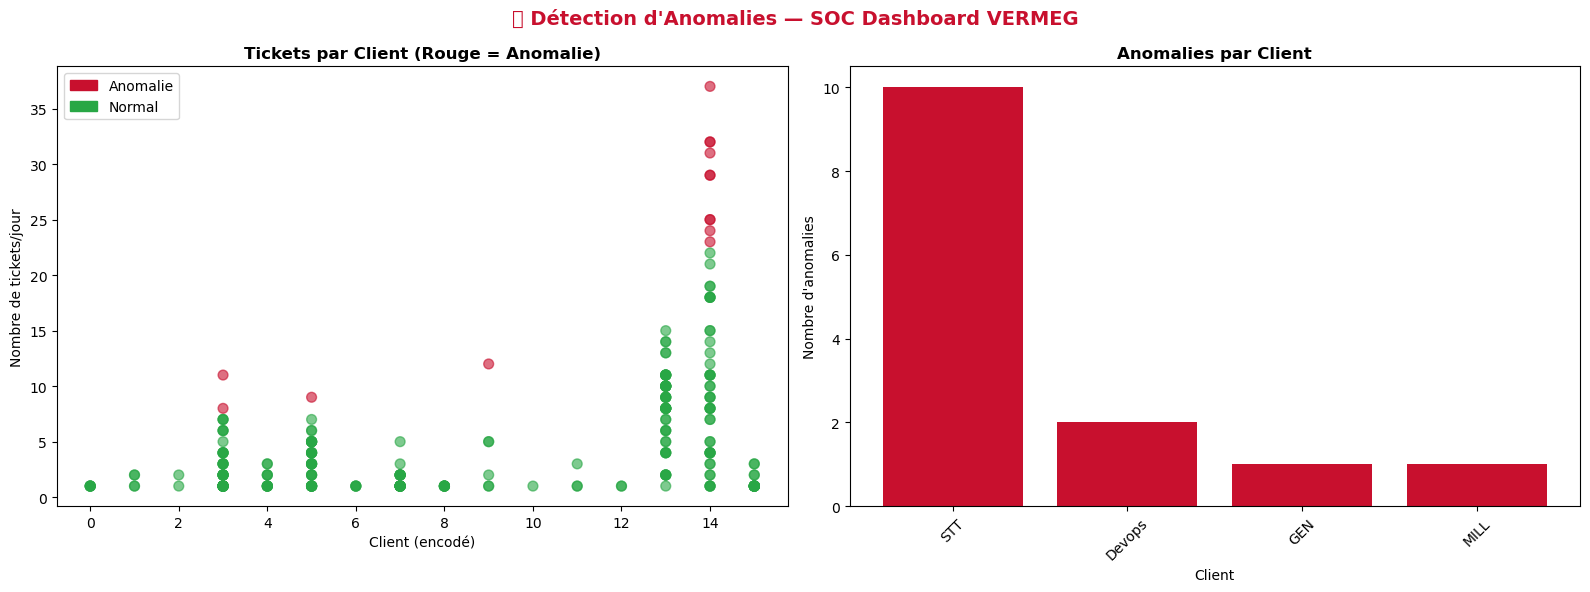


✅ Modèle anomalies sauvegardé !


In [49]:
# ============================================
# IA MODULE 2 — Détection d'anomalies
# ============================================

from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

df_anomaly = df_ai.copy()
df_anomaly['created'] = pd.to_datetime(df_anomaly['created'])
df_anomaly['date'] = df_anomaly['created'].dt.date

# Agrégation par client par jour
df_daily = df_anomaly.groupby(['date', 'client']).agg(
    ticket_count=('ticket_id', 'count'),
    total_hours=('hours_logged', 'sum')
).reset_index()

# Encoder clients
le2 = LabelEncoder()
df_daily['client_encoded'] = le2.fit_transform(df_daily['client'])

# Modèle Isolation Forest
X_anomaly = df_daily[['client_encoded', 'ticket_count', 'total_hours']]
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_daily['anomaly'] = iso_forest.fit_predict(X_anomaly)
df_daily['is_anomaly'] = df_daily['anomaly'] == -1

# Résultats
anomalies = df_daily[df_daily['is_anomaly']]
print(f"✅ Détection d'anomalies terminée !")
print(f"📊 Total jours analysés : {len(df_daily)}")
print(f"⚠️  Anomalies détectées : {len(anomalies)}")
print(f"\n🚨 Top anomalies :")
print("=" * 60)
top_anomalies = anomalies.sort_values('ticket_count', ascending=False).head(10)
for _, row in top_anomalies.iterrows():
    print(f"  {str(row['date']):<12} | {row['client']:<12} | {int(row['ticket_count'])} tickets | {row['total_hours']:.2f}h")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('🚨 Détection d\'Anomalies — SOC Dashboard VERMEG', fontsize=14, fontweight='bold', color='#C8102E')

# Graph 1 — Scatter par client
colors = ['#C8102E' if a else '#28a745' for a in df_daily['is_anomaly']]
axes[0].scatter(df_daily['client_encoded'], df_daily['ticket_count'], c=colors, alpha=0.6, s=50)
axes[0].set_title('Tickets par Client (Rouge = Anomalie)', fontweight='bold')
axes[0].set_xlabel('Client (encodé)')
axes[0].set_ylabel('Nombre de tickets/jour')
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#C8102E', label='Anomalie'), Patch(color='#28a745', label='Normal')])

# Graph 2 — Anomalies par client
anomaly_by_client = anomalies.groupby('client').size().sort_values(ascending=False)
axes[1].bar(anomaly_by_client.index, anomaly_by_client.values, color='#C8102E')
axes[1].set_title('Anomalies par Client', fontweight='bold')
axes[1].set_xlabel('Client')
axes[1].set_ylabel('Nombre d\'anomalies')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('anomalies_report.png', dpi=150, bbox_inches='tight')
plt.show()

joblib.dump(iso_forest, 'model_anomaly.pkl')
joblib.dump(le2, 'label_encoder_anomaly.pkl')
print("\n✅ Modèle anomalies sauvegardé !")

In [51]:
# ============================================
# IA MODULE 3 — API Flask
# ============================================

from flask import Flask, jsonify, request
from flask_cors import CORS
import joblib
import threading

app = Flask(__name__)
CORS(app)

# Charger les modèles
model_wl = joblib.load('model_workload.pkl')
model_an = joblib.load('model_anomaly.pkl')
le_wl = joblib.load('label_encoder.pkl')
le_an = joblib.load('label_encoder_anomaly.pkl')

@app.route('/ai/health', methods=['GET'])
def health():
    return jsonify({"status": "AI API Running"})

@app.route('/ai/predict-workload', methods=['GET'])
def predict_workload():
    results = []
    for client in sorted(le_wl.classes_):
        client_enc = le_wl.transform([client])[0]
        weekly_tickets = sum([
            model_wl.predict([[client_enc, day, 4, 18]])[0] 
            for day in range(5)
        ])
        weekly_hours = weekly_tickets * 0.25
        results.append({
            'client': client,
            'predicted_tickets': round(weekly_tickets),
            'predicted_hours': round(weekly_hours, 2)
        })
    results.sort(key=lambda x: x['predicted_tickets'], reverse=True)
    return jsonify({
        'predictions': results,
        'total_tickets': sum(r['predicted_tickets'] for r in results),
        'total_hours': round(sum(r['predicted_hours'] for r in results), 2)
    })

@app.route('/ai/detect-anomalies', methods=['GET'])
def detect_anomalies():
    import mysql.connector
    conn = mysql.connector.connect(
        host="localhost", user="root", password="", database="soc_dashboard"
    )
    df = pd.read_sql("SELECT * FROM etl_time_entries", conn)
    conn.close()
    
    df['created'] = pd.to_datetime(df['created'])
    df['date'] = df['created'].dt.date
    df_daily = df.groupby(['date', 'client']).agg(
        ticket_count=('ticket_id', 'count'),
        total_hours=('hours_logged', 'sum')
    ).reset_index()
    
    # Filtrer les clients connus
    known_clients = le_an.classes_
    df_daily = df_daily[df_daily['client'].isin(known_clients)]
    df_daily['client_encoded'] = le_an.transform(df_daily['client'])
    
    X = df_daily[['client_encoded', 'ticket_count', 'total_hours']]
    df_daily['anomaly'] = model_an.predict(X)
    
    anomalies = df_daily[df_daily['anomaly'] == -1].sort_values('ticket_count', ascending=False)
    
    return jsonify({
        'total_analyzed': len(df_daily),
        'anomalies_count': len(anomalies),
        'anomalies': anomalies[['date', 'client', 'ticket_count', 'total_hours']].astype(str).to_dict('records')
    })

# Lancer Flask dans un thread séparé
def run_flask():
    app.run(port=5001, debug=False, use_reloader=False)

thread = threading.Thread(target=run_flask)
thread.daemon = True
thread.start()

print("✅ API Flask IA démarrée sur http://localhost:5001")
print("📌 Endpoints disponibles :")
print("   GET /ai/health")
print("   GET /ai/predict-workload")
print("   GET /ai/detect-anomalies")

✅ API Flask IA démarrée sur http://localhost:5001
📌 Endpoints disponibles :
   GET /ai/health
   GET /ai/predict-workload
   GET /ai/detect-anomalies
